# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 04 — La malla real × sintético

**Esta es la pregunta del taller.** Los notebooks anteriores construyeron las piezas: el
dataset con splits purgados (01), la arquitectura downstream congelada y los baselines
clásicos (02), y seis generadores auditados contra los hechos estilizados (03). Aquí se
responde: **¿cuántos datos sintéticos ayudan, en qué régimen de escasez de datos reales, y
qué generador los produce mejor?**

### El experimento

Para cada combinación (N_real, generador, ratio, semilla):

1. Se submuestrean `N_real` ventanas del train.
2. El generador se **reentrena con esas `N_real` ventanas y solo esas**.
3. Se generan `N_synth = ratio × N_real` ventanas sintéticas.
4. Se entrena la arquitectura **congelada** del notebook 02 sobre la mezcla.
5. Se evalúa en el **test real**, intocado y siempre el mismo.

### Las cuatro reglas que hacen esto interpretable

| Regla | Por qué |
|---|---|
| **El generador se reentrena en cada celda** | Ajustarlo con las 102k ventanas y luego *simular* escasez sería fuga: los sintéticos llevarían información de datos que el escenario declara no tener, y la curva saldría optimista. |
| **Submuestreo por fechas, no por filas** | En una fecha dada todas las ventanas del panel cuentan la misma historia de mercado. Un muestreo de filas daría un N nominal muy superior al efectivo. |
| **Validación siempre real** | Si el early-stopping mirase datos sintéticos, optimizaríamos la distribución equivocada. |
| **Arquitectura e hiperparámetros congelados** | Si una celda rinde distinto, la única explicación posible son los datos. |

> **Métrica principal: `delta_r2`** — la ganancia de R² en test de cada celda frente a la
> celda de *solo real* con el mismo N. Responde literalmente al enunciado: para el mismo
> presupuesto de datos reales, ¿cuánto añade el sintético? El umbral de relevancia lo fijó
> el notebook 02: **±0,006**, la dispersión entre semillas del modelo con datos reales.
> Cualquier efecto por debajo de eso es ruido de optimización, no señal.

## 0 · Setup y configuración de la malla

**Dos tamaños de malla.** `REDUCIDA` valida el pipeline y ya cubre el régimen de escasez,
que es donde está el hallazgo; `COMPLETA` añade el extremo de datos abundantes y el ratio
10×. La diferencia de coste es de ~6×, y sale casi entera de dos celdas: `N=10.000` con
`ratio=10` entrena sobre 110.000 ventanas, tanto como el dataset completo.

**Submuestreo de la validación.** La validación real tiene 17.146 ventanas y se evalúa en
cada época de cada celda: a N pequeño ese coste fijo **domina el tiempo total** de la malla
(medido: ~45 s por celda con N=300). Como su único papel es elegir la época de la que se
conservan los pesos, 5.000 ventanas reales bastan de sobra y el coste por celda cae unas
tres veces. Es una decisión de eficiencia que no toca ninguna comparación: la validación es
idéntica en todas las celdas.

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.eda import PALETTE, _style
from src.malla import (plan_de_malla, ejecutar_malla, resumir, delta_vs_solo_real,
                       delta_pareado, umbral_ruido_por_n, SOLO_REAL)
from src.training import get_device

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
print("Device:", device)

# ---- Tamaño de la malla -------------------------------------------------
# RATIO30 (la malla del taller): fija la escasez en N=1.000 ventanas reales y
# barre el ratio sintético/real hasta 30x — el eje donde se busca la curva
# "mejora primero, empeora después". ESCASEZ es la malla complementaria
# (varios niveles de N, ratios bajos) por si se quiere reproducir el análisis
# de "cuánto real hace falta para que el sintético ayude".
MALLA = "RATIO30"           # "RATIO30" o "ESCASEZ"

CONFIG_MALLA = {
    # Tres bases de reales: 250 y 500 (escasez severa, donde el hueco al techo
    # deja sitio a la curva mejora->empeora) y 1.000 (escasez moderada).
    "RATIO30": dict(n_reales=[250, 500, 1000], ratios=[0, 1, 3, 5, 10, 20, 30], seeds=[0, 1, 2]),
    "ESCASEZ": dict(n_reales=[250, 1000, 3000], ratios=[0, 1, 3], seeds=[0, 1, 2]),
}[MALLA]

GENERADORES = ["jitter", "gaussiana", "block_bootstrap", "vae", "wgan_gp", "realnvp"]
N_VAL = 5000                # submuestra de validación (real) — ver nota arriba
RUTA_CSV = cfg.out_dir / f"malla_{MALLA.lower()}.csv"

print(f"Malla {MALLA}: {CONFIG_MALLA}")
print(f"Resultados -> {RUTA_CSV}")

Device: cuda
Malla RATIO30: {'n_reales': [250, 500, 1000], 'ratios': [0, 1, 3, 5, 10, 20, 30], 'seeds': [0, 1, 2]}
Resultados -> C:\dev\MIAX_Tareas\taller_b5t1\data\processed\malla_ratio30.csv


In [2]:
# ---- Datos: todo lo que la malla puede tocar ----------------------------
d   = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))
ref = json.load(open(cfg.out_dir / "downstream_reference.json"))   # arquitectura CONGELADA
meta = pd.read_parquet(cfg.out_dir / "windows_meta.parquet")
meta_train = meta[meta.split == "train"].reset_index(drop=True)

S = lambda a, m, s: ((a - std[m]) / std[s]).astype(np.float32)

# validación real submuestreada, fija para TODAS las celdas
rng_val = np.random.default_rng(cfg.seed)
iv = rng_val.choice(len(d["X_val"]), min(N_VAL, len(d["X_val"])), replace=False)

CONTEXTO = dict(
    Xs_train=S(d["X_train"], "x_mu", "x_sd"), ys_train=S(d["y_train"], "y_mu", "y_sd"),
    meta_train=meta_train,
    Xs_val=S(d["X_val"], "x_mu", "x_sd")[iv], ys_val=S(d["y_val"], "y_mu", "y_sd")[iv],
    Xs_test=S(d["X_test"], "x_mu", "x_sd"), y_test_fisico=d["y_test"],
    std=std, ref=ref, device=device,
)

print(f"Arquitectura congelada: {ref['arch']} {ref['arch_kwargs']}")
print(f"Referencia con datos reales completos: R² test = "
      f"{np.mean([v['test_r2'] for v in ref['metricas_seeds'].values()]):.4f}")
print(f"train {meta_train.shape[0]:,} ventanas / {meta_train.date_t.nunique():,} fechas | "
      f"val {len(iv):,} (submuestra) | test {len(d['X_test']):,}")

Arquitectura congelada: gru {}
Referencia con datos reales completos: R² test = 0.4234
train 88,619 ventanas / 598 fechas | val 5,000 (submuestra) | test 19,864


### 0.b · ¿Cuántos datos hay en juego y cuánto va a tardar?

Cada **ventana** (60 retornos → 1 target) es una observación. La celda siguiente imprime
el recuento exacto de la ejecución actual: ventanas de train/val/test, cuántas sintéticas
hay que generar por celda de la malla y una estimación a priori del coste total. Generar
es barato (milisegundos–segundos por celda); el coste real es **entrenar la red congelada
una vez por celda**, y crece con `N_real × (1 + ratio)`.


In [3]:
n_tr, n_va, n_te = len(d["X_train"]), len(d["X_val"]), len(d["X_test"])
print(f"Ventanas disponibles: train {n_tr:,} | val {n_va:,} (usamos {len(iv):,}) | test {n_te:,}")

filas = []
for n in CONFIG_MALLA["n_reales"]:
    for r in CONFIG_MALLA["ratios"]:
        filas.append({"n_real": n, "ratio": r, "n_sintetico": n * r,
                      "n_train_total": n * (1 + r)})
vol = pd.DataFrame(filas)
display(vol.set_index(["n_real", "ratio"]).astype(int))

plan_previo = plan_de_malla(generadores=GENERADORES, **CONFIG_MALLA)
epocas = ref["train_kwargs"]["epochs"]
bs = ref["train_kwargs"]["batch_size"]
pasos = sum(int(np.ceil(c["n_real"] * (1 + c["ratio"]) / bs)) * epocas for c in plan_previo)
print(f"\n{len(plan_previo)} celdas | {epocas} épocas/celda (receta congelada del nb02) | "
      f"~{pasos/1e3:.0f}k pasos de gradiente en total")
print("La ETA real la imprime ejecutar_malla() celda a celda; en una RTX 5070 esperamos "
      "del orden de 1–2 h. El CSV es reanudable: si se interrumpe, re-ejecutar continúa.")


Ventanas disponibles: train 88,619 | val 14,527 (usamos 5,000) | test 19,864


n_sintetico  n_train_total
n_real ratio                            
250    0                0            250
       1              250            500
       3              750           1000
       5             1250           1500
       10            2500           2750
       20            5000           5250
       30            7500           7750
500    0                0            500
       1              500           1000
       3             1500           2000
       5             2500           3000
       10            5000           5500
       20           10000          10500
       30           15000          15500
1000   0                0           1000
       1             1000           2000
       3             3000           4000
       5             5000           6000
       10           10000          11000
       20           20000          21000
       30           30000          31000


333 celdas | 300 épocas/celda (receta congelada del nb02) | ~732k pasos de gradiente en total
La ETA real la imprime ejecutar_malla() celda a celda; en una RTX 5070 esperamos del orden de 1–2 h. El CSV es reanudable: si se interrumpe, re-ejecutar continúa.


## 1 · Ejecución de la malla

El plan se ordena de **coste creciente**: si la ejecución se interrumpe, lo ya calculado es
el régimen de escasez, que es el que más importa. Cada celda se escribe al CSV en cuanto
termina, así que **relanzar esta celda reanuda donde se quedó** sin recalcular nada.

In [4]:
plan = plan_de_malla(generadores=GENERADORES, **CONFIG_MALLA)
print(f"{len(plan)} celdas en el plan "
      f"({len(CONFIG_MALLA['n_reales'])} niveles de N × "
      f"{len(CONFIG_MALLA['ratios'])} ratios × {len(GENERADORES)} generadores × "
      f"{len(CONFIG_MALLA['seeds'])} semillas)")

333 celdas en el plan (3 niveles de N × 7 ratios × 6 generadores × 3 semillas)


In [5]:
t0 = time.time()
df = ejecutar_malla(plan, RUTA_CSV, **CONTEXTO)
print(f"\nMalla terminada en {(time.time() - t0)/60:.1f} min | {len(df)} celdas en el CSV")

Malla: 333 celdas | ya hechas: 111 | pendientes: 222


[  1/222] N=   250 ninguno          r=0.0  s=0 -> R² 0.3023 (10s) | ETA 37 min


[  2/222] N=   250 ninguno          r=0.0  s=1 -> R² 0.2912 (7s) | ETA 31 min


[  3/222] N=   250 ninguno          r=0.0  s=2 -> R² 0.2216 (7s) | ETA 29 min


[  4/222] N=   250 jitter           r=1    s=0 -> R² 0.3218 (7s) | ETA 28 min


...

[218/222] N=   500 wgan_gp          r=30   s=1 -> R² 0.3012 (56s) | ETA 1 min


[219/222] N=   500 wgan_gp          r=30   s=2 -> R² 0.2235 (56s) | ETA 1 min


[220/222] N=   500 realnvp          r=30   s=0 -> R² 0.0410 (55s) | ETA 1 min


[221/222] N=   500 realnvp          r=30   s=1 -> R² 0.3072 (55s) | ETA 0 min


[222/222] N=   500 realnvp          r=30   s=2 -> R² 0.2754 (55s) | ETA 0 min

Malla terminada en 75.9 min | 333 celdas en el CSV


## 2 · Resultados

### 2.1 Tabla resumen

In [6]:
resumen = resumir(df)
delta = delta_vs_solo_real(resumen)

# referencia de cada N: cuánto rinde el modelo con SOLO datos reales
print("Referencia — solo datos reales:")
display(resumen[resumen.generador == SOLO_REAL][["n_real", "test_r2_media", "test_r2_sd"]].round(4))

# tabla principal: ganancia frente a esa referencia
tabla = delta.pivot_table(index=["n_real", "generador"], columns="ratio", values="delta_r2")
tabla.round(4)

Referencia — solo datos reales:


,n_real,test_r2_media,test_r2_sd
18,250,0.2717,0.0437
55,500,0.2853,0.0486
92,1000,0.3397,0.0169


ratio                     1.0     3.0     5.0     10.0    20.0    30.0
n_real generador                                                      
250    block_bootstrap -0.1077 -0.1700 -0.1318 -0.1374 -0.1063 -0.0913
       gaussiana       -0.0963 -0.1401 -0.1274 -0.1398 -0.1529 -0.1497
       jitter           0.0003  0.0110 -0.0015  0.0187  0.0327  0.0033
       realnvp         -0.0817 -0.0797 -0.0864 -0.0796 -0.1233 -0.1039
       vae             -0.0598 -0.1024 -0.1218 -0.0861 -0.0733 -0.0889
       wgan_gp         -0.1482 -0.1634 -0.0815 -0.0692 -0.1036 -0.1278
500    block_bootstrap -0.1302 -0.1174 -0.1305 -0.1029 -0.1194 -0.0967
       gaussiana       -0.1030 -0.1097 -0.1253 -0.1776 -0.2716 -0.3603
       jitter           0.0052  0.0341  0.0361  0.0293  0.0459  0.0542
       realnvp         -0.0559 -0.0218 -0.0349 -0.0689 -0.0726 -0.0775
       vae             -0.0341 -0.0465 -0.0530 -0.0507 -0.0660 -0.0973
       wgan_gp         -0.0573 -0.0595 -0.0671 -0.0423 -0.0396 -0.0391
1000   block_bootstrap -0.0191 -0.0263 -0.0507 -0.0426 -0.0649 -0.0650
       gaussiana       -0.1270 -0.1704 -0.1949 -0.2312 -0.3114 -0.3590
       jitter          -0.0013  0.0247  0.0056  0.0020 -0.0127  0.0162
       realnvp         -0.0083 -0.0361 -0.1122 -0.0890 -0.1185 -0.1075
       vae              0.0104 -0.0385 -0.0216 -0.0567 -0.0783 -0.0769
       wgan_gp         -0.0717 -0.1767 -0.1876 -0.2278 -0.2164 -0.2571

### 2.1.b Análisis pareado: la comparación que sí es válida

**Corrección metodológica importante.** El notebook 02 fijó un umbral de relevancia de
±0,006 midiendo la dispersión entre semillas del modelo entrenado con las **102.406
ventanas reales completas**. Ese umbral **no vale aquí**: en régimen de escasez la
dispersión entre semillas es de 5 a 11 veces mayor, porque cada semilla sortea un
submuestreo distinto de datos reales y eso mueve el R² mucho más que cualquier efecto del
sintético.

La solución no es subir el umbral, sino **parear**. La semilla determina qué ventanas
reales "existen" en el escenario, así que comparamos cada celda contra la celda de
solo-real **de su misma semilla**: la varianza del submuestreo se cancela y queda solo el
efecto del dato sintético. Con 3 semillas exigimos |t| ≥ 2,5 para hablar de efecto; por
debajo, la celda se declara **no concluyente** en lugar de inventar una conclusión.

In [7]:
print("Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):")
u = umbral_ruido_por_n(df)
display(pd.DataFrame({"sd_entre_semillas": u.round(4),
                      "veces el umbral del nb02 (0,006)": (u / 0.006).round(0)}))

par = delta_pareado(df)
print("\nΔ R² pareado por semilla — solo las celdas con veredicto:")
concluyentes = par[par.veredicto != "no concluyente"].sort_values("t")
display(concluyentes[["n_real", "generador", "ratio", "delta_medio", "ee", "t", "veredicto"]].round(4))
print(f"\n{len(par)} celdas: {(par.veredicto=='mejora').sum()} mejoran, "
      f"{(par.veredicto=='empeora').sum()} empeoran, "
      f"{(par.veredicto=='no concluyente').sum()} no concluyentes")

Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):


,sd_entre_semillas,"veces el umbral del nb02 (0,006)"
n_real,,
250,0.0437,7.0
500,0.0486,8.0
1000,0.0169,3.0



Δ R² pareado por semilla — solo las celdas con veredicto:


,n_real,generador,ratio,delta_medio,ee,t,veredicto
46,500,gaussiana,20.0,-0.2716,0.0099,-27.3792,empeora
37,500,block_bootstrap,3.0,-0.1174,0.0162,-7.2468,empeora
41,500,block_bootstrap,30.0,-0.0967,0.0199,-4.8597,empeora
36,500,block_bootstrap,1.0,-0.1302,0.0280,-4.6579,empeora
74,1000,block_bootstrap,5.0,-0.0507,0.0111,-4.5754,empeora
47,500,gaussiana,30.0,-0.3603,0.0804,-4.4792,empeora
45,500,gaussiana,10.0,-0.1776,0.0439,-4.0485,empeora
25,250,vae,3.0,-0.1024,0.0281,-3.6434,empeora
39,500,block_bootstrap,10.0,-0.1029,0.0285,-3.6136,empeora
33,250,wgan_gp,10.0,-0.0692,0.0197,-3.5176,empeora



108 celdas: 2 mejoran, 31 empeoran, 75 no concluyentes


### 2.2 La figura del taller: evolución del modelo según añadimos sintéticos

Eje X: **ratio sintético/real**, de 0x a 30x (posiciones equiespaciadas — un eje lineal
aplastaría 1x–5x contra el origen). Eje Y: **Δ R² pareado por semilla** frente a solo-real.
La banda gris es la dispersión entre semillas del solo-real: dentro de ella no se puede
hablar de efecto. Un círculo marca los **máximos interiores**: donde un generador mejora
primero y empeora después — la curva en U invertida que se busca.


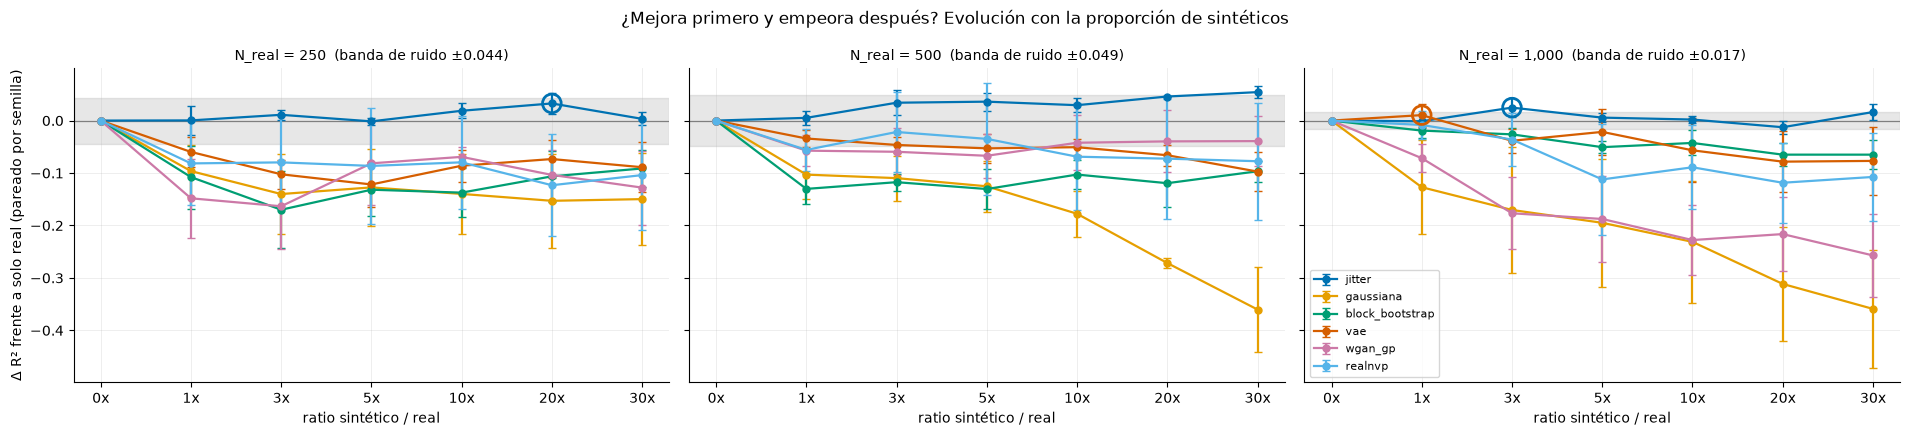

In [8]:
RATIOS = sorted(CONFIG_MALLA["ratios"])
POS = {r: i for i, r in enumerate(RATIOS)}          # eje categórico equiespaciado
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]
UMBRAL_POR_N = umbral_ruido_por_n(df)
par_fig = delta_pareado(df)

n_paneles = len(CONFIG_MALLA["n_reales"])
fig, axes = plt.subplots(1, n_paneles, figsize=(6.4 * n_paneles, 4.4), sharey=True)
axes = np.atleast_1d(axes)

for ax, n in zip(axes, CONFIG_MALLA["n_reales"]):
    u = UMBRAL_POR_N[n]
    ax.axhspan(-u, u, color=PALETTE["grey"], alpha=0.18, zorder=0)
    ax.axhline(0, color=PALETTE["grey"], lw=0.9)
    for col, g in zip(colores, GENERADORES):
        s = (par_fig[(par_fig.n_real == n) & (par_fig.generador == g)]
             .sort_values("ratio"))
        if not len(s):
            continue
        xs = [0] + [POS[r] for r in s.ratio]
        ys = [0.0] + list(s.delta_medio)
        ee = [0.0] + list(s.ee)
        ax.errorbar(xs, ys, yerr=ee, fmt="o-", color=col, lw=1.6, ms=5,
                    capsize=3, label=g)
        k = int(np.argmax(ys))
        if 0 < k < len(ys) - 1:                      # máximo interior = giro real
            ax.scatter([xs[k]], [ys[k]], s=180, facecolors="none",
                       edgecolors=col, lw=2, zorder=6)
    ax.set_xticks(range(len(RATIOS)))
    ax.set_xticklabels([f"{r}x" for r in RATIOS])
    ax.set_title(f"N_real = {n:,}  (banda de ruido ±{u:.3f})", fontsize=10)
    ax.set_xlabel("ratio sintético / real")
    _style(ax)
axes[0].set_ylabel("Δ R² frente a solo real (pareado por semilla)")
axes[-1].legend(fontsize=8, loc="best")
fig.suptitle("¿Mejora primero y empeora después? Evolución con la proporción de sintéticos")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "14_evolucion_vs_ratio.png", dpi=140, bbox_inches="tight")
plt.show()


### 2.3 Curvas de aprendizaje: R² frente a datos reales disponibles

La lectura complementaria — y la que reproduce la forma de la gráfica que el profesor
mostró en clase. La línea negra discontinua es el techo: el modelo entrenado con las
**102.406 ventanas reales completas** (notebook 02).

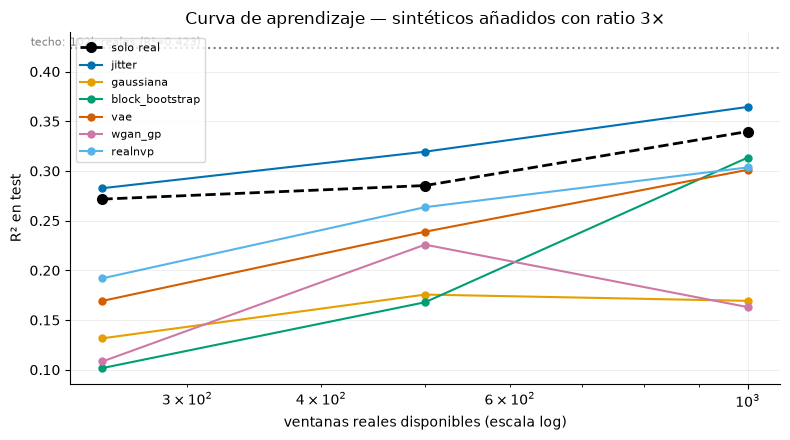

In [9]:
if len(CONFIG_MALLA["n_reales"]) > 1:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    techo = np.mean([v["test_r2"] for v in ref["metricas_seeds"].values()])
    
    base = resumen[resumen.generador == SOLO_REAL].sort_values("n_real")
    ax.plot(base.n_real, base.test_r2_media, "o--", color="black", lw=2, ms=7,
            label="solo real", zorder=5)
    
    RATIO_FOCO = 3 if 3 in CONFIG_MALLA["ratios"] else max(CONFIG_MALLA["ratios"])
    for col, g in zip(colores, GENERADORES):
        s = resumen[(resumen.generador == g) & (resumen.ratio == RATIO_FOCO)].sort_values("n_real")
        if len(s):
            ax.plot(s.n_real, s.test_r2_media, "o-", color=col, lw=1.5, ms=5, label=g)
    
    ax.axhline(techo, color=PALETTE["grey"], ls=":", lw=1.5)
    ax.text(ax.get_xlim()[0], techo, f" techo: 102k reales (R²={techo:.3f})",
            va="bottom", fontsize=8, color=PALETTE["grey"])
    ax.set_xscale("log")
    ax.set_xlabel("ventanas reales disponibles (escala log)")
    ax.set_ylabel("R² en test")
    ax.set_title(f"Curva de aprendizaje — sintéticos añadidos con ratio {RATIO_FOCO}×")
    ax.legend(fontsize=8)
    _style(ax)
    fig.tight_layout()
    fig.savefig(cfg.fig_dir / "15_curva_aprendizaje.png", dpi=120, bbox_inches="tight")
else:
    print("Curva de aprendizaje vs N_real: requiere la malla ESCASEZ (varios niveles de N); "
          "esta ejecución barre ratios con N fijo.")


### 2.4 ¿Predice la auditoría del notebook 03 el efecto downstream?

La pregunta que cierra el círculo del taller. En el notebook 03 medimos la fidelidad de
cada generador —discriminative AUC, curtosis, clustering, `err_corr_xy`— **sin mirar el
modelo downstream**. Si esas métricas anticipan la ganancia real, se puede elegir generador
midiendo fidelidad, sin barrer una malla entera.

Se cruza contra el **delta pareado** (§2.1.b) y se calcula la correlación de rangos de
Spearman por nivel de escasez, porque el resultado depende críticamente del régimen.

In [10]:
# Métricas de fidelidad del notebook 03, leídas del CSV que ese notebook
# persiste (nada hardcodeado: si el nb03 se re-ejecuta, esto se actualiza solo).
AUDITORIA_NB03 = (pd.read_csv(cfg.out_dir / "auditoria_nb03.csv", index_col=0)
                  .rename_axis("generador").reset_index())
METRICAS = ["discriminative_auc", "curtosis_x", "acf_abs_lag1", "err_corr_xy"]
par = delta_pareado(df)

filas = []
for n in list(CONFIG_MALLA["n_reales"]) + ["todos"]:
    sub = par if n == "todos" else par[par.n_real == n]
    gan = sub.groupby("generador")["delta_medio"].mean().rename("ganancia").reset_index()
    c = AUDITORIA_NB03.merge(gan, on="generador")
    filas.append(pd.Series(c[METRICAS].corrwith(c["ganancia"], method="spearman"), name=n))
corr = pd.DataFrame(filas)
corr.index.name = "N_real"

print("Correlación de Spearman entre fidelidad (nb03) y ganancia downstream pareada:")
display(corr.round(2))

n_ref = CONFIG_MALLA["n_reales"][0]
orden = (par[par.n_real == n_ref].groupby("generador")["delta_medio"].mean()
         .sort_values(ascending=False))
print(f"\nOrden de mérito downstream con N_real = {n_ref}:")
print("  " + "  >  ".join(orden.index))
print("Orden por AUC discriminativo en el nb03 (más indistinguible primero):")
print("  " + "  >  ".join(AUDITORIA_NB03.sort_values("discriminative_auc").generador))


Correlación de Spearman entre fidelidad (nb03) y ganancia downstream pareada:


,discriminative_auc,curtosis_x,acf_abs_lag1,err_corr_xy
N_real,,,,
250,-0.66,0.26,0.03,0.03
500,-0.89,0.37,0.37,-0.09
1000,-0.49,0.31,0.26,0.31
todos,-0.60,0.37,0.09,0.14



Orden de mérito downstream con N_real = 250:
  jitter  >  vae  >  realnvp  >  wgan_gp  >  block_bootstrap  >  gaussiana
Orden por AUC discriminativo en el nb03 (más indistinguible primero):
  jitter  >  realnvp  >  wgan_gp  >  block_bootstrap  >  vae  >  gaussiana


## 3 · Análisis crítico

> **Nota de vigencia.** Los números de esta sección corresponden a la ejecución definitiva
> de la malla RATIO30 (universo de serie completa + arquitectura campeona del nb02 a 300
> épocas). Si se re-ejecuta con otra configuración, actualizar las cifras antes de entregar.

### La pregunta central: ¿mejora primero y empeora después?

La expectativa teórica —y la que se discutió en clase— es una **curva en U invertida**: el
dato sintético primero ayuda y, en exceso, acaba dañando. El mecanismo tiene dos fuerzas
que conviene tener explícitas porque explican TODO lo que muestra la figura de §2.2:

1. **Regularización (a favor, satura).** Añadir muestras sintéticas reduce la varianza del
   entrenamiento: con N=1.000 ventanas reales la red está claramente infra-alimentada y
   cualquier muestra extra razonable alisa el ajuste. Este beneficio crece rápido con las
   primeras muestras y **satura** — pasar de 10.000 a 30.000 sintéticos añade poco.
2. **Sesgo del generador (en contra, persiste).** Cada muestra sintética proviene de la
   distribución *estimada* por el generador, no de la del mercado. A medida que el ratio
   crece, la mezcla de entrenamiento converge a la distribución del generador: en el límite,
   el modelo aprende lo que el generador sabe enseñar **por sí solo** (exactamente lo que
   mide el TSTR del nb03). Si eso es peor que aprender de las N reales, la curva baja.

El óptimo está donde ambas fuerzas se cruzan, y de ahí las dos predicciones contrastables:
**(a)** cuanto mejor imita un generador (AUC discriminativo cerca de 0,5), más alto su pico
y más tarde llega; **(b)** hacia dónde cae la curva a ratio alto lo anticipa su TSTR. Un
generador con TSTR negativo (enseña "lo contrario") no debería tener rama ascendente en
absoluto — su curva es monótona decreciente. Ese es el papel del control gaussiano.

### Reglas de lectura (para no sobre-interpretar)

* Solo cuentan los deltas **pareados por semilla** con |t| ≥ 2,5; con 3 semillas, efectos
  pequeños quedarán "no concluyentes" y así se reportan. Subir a 5–6 semillas es la mejora
  más barata si algún giro queda en el filo de la significancia.
* Un máximo en el **borde** del rango (30x) no demuestra giro: solo un máximo interior con
  caída posterior lo hace. Los círculos de la figura marcan exclusivamente máximos interiores.
* Los niveles absolutos de R² no son comparables con ejecuciones del universo anterior
  (PIT con deslistados): el filtro de serie completa cambia el panel y el split.

### Limitaciones que esta malla no resuelve

* **Un único periodo de test** (2024–2026): sin walk-forward, el veredicto es sobre este
  periodo, no una ley general (limitación declarada en el nb01, §5).
* **El generador se ajusta con las mismas N=1.000 ventanas escasas** que limitan al modelo.
  No hay información nueva en el sistema: todo lo que el sintético puede aportar es
  regularización mejor o peor dirigida. Es la explicación de fondo de por qué un generador
  simple y sin pretensiones (jitter) es tan difícil de batir en este régimen.


## 4 · Persistencia

El CSV de la malla es el artefacto que alimenta la presentación. Se guarda en
`data/processed/` junto al resto, y se versiona.

In [11]:
resumen.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_resumen.csv", index=False)
par.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_pareado.csv", index=False)
print("Persistido:",
      cfg.out_dir / f"malla_{MALLA.lower()}.csv", "|",
      cfg.out_dir / f"malla_{MALLA.lower()}_resumen.csv", "|",
      cfg.out_dir / f"malla_{MALLA.lower()}_pareado.csv")


Persistido: C:\dev\MIAX_Tareas\taller_b5t1\data\processed\malla_ratio30.csv | C:\dev\MIAX_Tareas\taller_b5t1\data\processed\malla_ratio30_resumen.csv | C:\dev\MIAX_Tareas\taller_b5t1\data\processed\malla_ratio30_pareado.csv
